<a href="https://colab.research.google.com/github/johanordonez/CIENCIA-DE-DATOS---MAIE-2026A/blob/main/03_icd_taller3_va_continuas_JOHAN_ORDO%C3%91EZ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ESTUDIANTE:** JOHAN DAVID ORDOÑEZ CASTRO - **CODIGO:** 224393001


# **¡¡ ANTES DE EMPEZAR !!**

Deshabilita autocompletar con IA. Esta acción te ayudará a aprender de verdad. Si estás en Colab sigue estos pasos:



1.   Ir a Herramientas \ Configuración \ Asistencia de IA
2.   Desactivar la casilla **"Mostrar autocompletado impulsado por IA"**
3.   Activar la casilla **"Ocultar funciones de IA generativa"**


# **SIMULACIÓN DE VARIABLES ALEATORIAS A PARTIR DE DISTRIBUCIONES**

Antes de trabajar con variables aleatorias continuas, apliquemos el método de la inversa de la CDF para generar variables aleatorias con cierta distribución.

# Reto 0: La Cafetería:

Usted está asesorando a una cafetería local para estimar sus ganancias diarias. Sabe que reciben **150 clientes al día** entre las 8:00 a.m. y las 8:00 p.m. (20:00).

A través de la observación, ha determinado dos comportamientos clave:

**1. La Hora de Llegada:**
Los clientes no llegan de manera uniforme. Hay un pico de oficinistas a las 10:00 a.m. y un pico de estudiantes a las 3:00 p.m. (15:00). La probabilidad de que un cliente llegue en una hora específica está dada por la siguiente Función de Masa:
* `Horas: 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20`
* `Probabilidades: 2%, 8%, 20%, 10%, 5%, 5%, 10%, 20%, 10%, 5%, 3%, 1%, 1%`

**2. El Tipo de Consumo:**
* **El Turno Mañana (Antes de las 12:00 m):** La gente tiene prisa. Tienen un **80%** de probabilidad de pedir el *Café Estándar* (\$1 USD) y un 20% de pedir el *Café de Especialidad* (\$2 USD).
* **El Turno Tarde (12:00 m en adelante):** La gente va a relajarse o estudiar. Tienen un **70%** de probabilidad de pedir el *Café de Especialidad* y un 30% de pedir el *Estándar*.

**Entregable:**
Simular 1,000 días completos de operación para encontrar la distribución de las ganancias diarias. ¿Cuál es la probabilidad de que las ganancias estén por debajo de \$ 250 USD?

**Nota:** La función `np.random.rand()` disponible en la librería `numpy` genera un número aleatorio entre 0 y 1 con distribución uniforme.

In [ ]:
import numpy as np
# --- 1. CONFIGURACIÓN INICIAL ---
DIAS_SIMULACION = 1000
CLIENTES_POR_DIA = 150
PRECIO_ESTANDAR = 1
PRECIO_ESPECIALIDAD = 2

# Datos de entrada
horas = np.arange(8, 21) # [8, 9, ..., 20]
prob_llegada = [0.02, 0.08, 0.20, 0.10, 0.05, 0.05, 0.10, 0.20, 0.10, 0.05, 0.03, 0.01, 0.01]

# Simulación por dia
def simulacion_dia():
  ganancias_dia=0
  # --- 2. ASIGNACIÓN DE HORAS ---
  # Elegimos la hora de llegada para cada uno de los 150 clientes según su probabilidad
  llegadas_clientes = np.random.choice(horas, size=CLIENTES_POR_DIA, p=prob_llegada) # tamaño, cuantas veces se simula, probabilidades segun la hora

  for hora in llegadas_clientes:
    # Generar un número aleatorio entre 0 y 1 para decidir la compra
    comrpa_aleatoria= np.random.rand()
    # --- 3. LÓGICA DE CONSUMO (MAÑANA VS TARDE) ---
    if hora < 12:
        if comrpa_aleatoria < 0.80:
          ganancias_dia += PRECIO_ESTANDAR
        else:
          ganancias_dia += PRECIO_ESPECIALIDAD
    else:
        if comrpa_aleatoria < 0.30:
          ganancias_dia += PRECIO_ESTANDAR
        else:
          ganancias_dia += PRECIO_ESPECIALIDAD
  return ganancias_dia

# --- 4. EJECUCIÓN DE LA SIMULACIÓN ---
historial_ganancias = np.array([simulacion_dia() for x in range(DIAS_SIMULACION)])

# --- 5. ANÁLISIS DE RESULTADOS ---
ganancia_promedio = historial_ganancias.mean()
std_gan = historial_ganancias.std()
prob_bajo_250 = np.mean(historial_ganancias < 250) * 100

print("=" * 70)
print("  RESULTADOS — SIMULACIÓN CAFETERÍA")
print("=" * 70)
print(f"  Ganancia promedio diaria  : ${ganancia_promedio:.2f} USD")
print(f"  Desviación estándar       : ${std_gan:.2f} USD")
print(f"  Ganancia mínima           : ${historial_ganancias.min():.2f} USD")
print(f"  Ganancia máxima           : ${historial_ganancias.max():.2f} USD")
print(f"  La probabilidad de que las ganancias estén por debajo de $ 250 es \n  P(ganancia < $250 USD)    : {int(prob_bajo_250)} %")
print("=" * 70)

  RESULTADOS — SIMULACIÓN CAFETERÍA
  Ganancia promedio diaria  : $225.10 USD
  Desviación estándar       : $6.38 USD
  Ganancia mínima           : $205.00 USD
  Ganancia máxima           : $247.00 USD
  La probabilidad de que las ganancias estén por debajo de $ 250 es 
  P(ganancia < $250 USD)    : 100 %


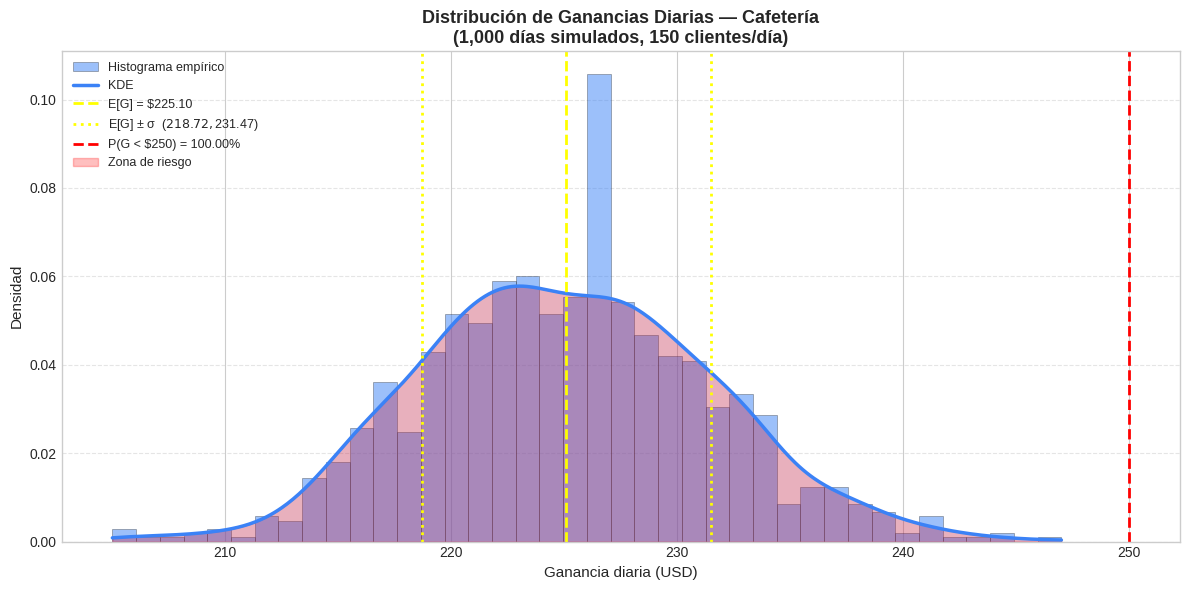

In [ ]:
# ==========================================
# GRÁFICO: Distribución de Ganancias Diarias
# ==========================================
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(12, 6))
# --- Histograma ---
ax.hist(historial_ganancias, bins=40, color='#3b82f6',
        edgecolor='black', linewidth=0.4, alpha=0.5,
        density=True, label='Histograma empírico')
# --- KDE ---
kde    = gaussian_kde(historial_ganancias)
x_vals = np.linspace(historial_ganancias.min(), historial_ganancias.max(), 500)
y_vals = kde(x_vals)
ax.plot(x_vals, y_vals, color='#3b82f6', linewidth=2.5, label='KDE')
# --- Área bajo la curva ---
ax.fill_between(x_vals, y_vals, alpha=0.15, color='#3b82f6')
# --- Línea E[G] ± σ ---
ax.axvline(ganancia_promedio, color='yellow', linewidth=2, linestyle='--',
           label=f"E[G] = ${ganancia_promedio:.2f}")
ax.axvline(ganancia_promedio - std_gan, color='yellow', linewidth=2, linestyle=':')
ax.axvline(ganancia_promedio + std_gan, color='yellow', linewidth=2, linestyle=':',
           label=f"E[G] ± σ  (${ganancia_promedio-std_gan:.2f} , ${ganancia_promedio+std_gan:.2f})")
# --- Línea umbral $250 ---
ax.axvline(250, color='red', linewidth=2, linestyle='--',
           label=f"P(G < $250) = {prob_bajo_250:.2f}%")
# --- Área de riesgo (ganancias < $250) ---
x_riesgo = x_vals[x_vals < 250]
y_riesgo = kde(x_riesgo)
ax.fill_between(x_riesgo, y_riesgo, color='red', alpha=0.25,
                label='Zona de riesgo')
# --- Estética ---
ax.set_title(f'Distribución de Ganancias Diarias — Cafetería\n'
             f'({DIAS_SIMULACION:,} días simulados, {CLIENTES_POR_DIA} clientes/día)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Ganancia diaria (USD)', fontsize=11)
ax.set_ylabel('Densidad', fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# **VARIABLES ALEATORIAS CONTINUAS**

Vamos a analizar el **S&P 500**, un índice que agrupa el valor de las acciones de las 500 empresas más grandes de Estados Unidos (Apple, Microsoft, Amazon, etc.). Este índice no solo es el termómetro más preciso de la economía global, sino que es el estándar contra el cual los inversores comparan el rendimiento de sus carteras en bolsa, e incluso de otras alternativas de inversión como los CDTs o el sector inmobiliario

En finanzas, rara vez analizamos el precio bruto de una acción. Lo que realmente nos importa es el **Retorno Diario**, es decir, qué porcentaje subió o bajó el precio respecto al día anterior. El retorno diario es un buen ejemplo de una **Variable Aleatoria Continua**:

**Haremos lo siguiente:**
1. Descargar los datos históricos del S&P 500 de los últimos 5 años.
2. Calcular los retornos diarios porcentuales.
3. Graficar un histograma para descubrir la "forma" de esta variable aleatoria.

In [ ]:
# ==========================================
# 0. PREPARACIÓN E INSTALACIÓN DE LIBRERÍAS
# ==========================================

# Instalamos la librería yfinance (Yahoo Finance)
!pip install yfinance -q

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configuramos un estilo limpio para las gráficas
plt.style.use('seaborn-v0_8-whitegrid')


In [ ]:
# ==========================================
# 1. DESCARGA DE DATOS
# ==========================================

print("Descargando datos del S&P 500...")
sp500 = yf.download('^GSPC', period='5y')

# Seleccionamos el cierre. Usamos doble corchete [['Close']] para asegurar
# que siga siendo un DataFrame (y no una Serie) y hacemos una copia limpia
sp500 = sp500[['Close']].copy()

# Veamos cómo son los datos que acabamos de descargar:
display(sp500.head())

# 1. Renombramos el título del índice (que originalmente es 'Date')
sp500 = sp500.rename_axis('fecha')

# 2. Renombramos la única columna de datos que tenemos
sp500.columns = ['precio']

print("\nPrimeros registros del precio:")
display(sp500.head())


/tmp/ipykernel_1314/3148702537.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download('^GSPC', period='5y')
[*********************100%***********************]  1 of 1 completed

Descargando datos del S&P 500...


Price,Close
Ticker,^GSPC
Date,
2021-03-08,3821.350098
2021-03-09,3875.439941
2021-03-10,3898.810059
2021-03-11,3939.340088
2021-03-12,3943.340088



Primeros registros del precio:


,precio
fecha,
2021-03-08,3821.350098
2021-03-09,3875.439941
2021-03-10,3898.810059
2021-03-11,3939.340088
2021-03-12,3943.340088


Para analizar una serie de tiempo financiera, el precio diario importa menos que los retornos porcentuales.
$$
  \text{retorno_diario}=\frac{\text{precio_actual}-\text{precio_ayer}}{\text{precio_ayer}}
$$

Vamos a calcular estos retornos en nuestros datos

In [ ]:
# ==========================================
# 2. PRE-PROCESAMIENTO
# ==========================================

# Usando.shift(1) movemos los datos una posición hacia abajo (el precio de ayer).

sp500['precio_ayer'] = sp500['precio'].shift(1)
display(sp500.head())
# Calculamos el retorno porcentual de forma manual (para entender la matemática)
#sp500['retorno_diario'] = (sp500['precio'] - sp500['precio_ayer']) / sp500['precio_ayer']

# Forma optimizada de Pandas (hace lo mismo que arriba)
sp500['retorno_diario'] = sp500['precio'].pct_change() # Descomenta esta línea para usar la versión optimizada

# Limpiamos los datos nulos generados por el shift (la primera fila no tiene "ayer")
sp500.dropna(inplace=True)

display(sp500.head())


,precio,precio_ayer
fecha,,
2021-03-08,3821.350098,NaN
2021-03-09,3875.439941,3821.350098
2021-03-10,3898.810059,3875.439941
2021-03-11,3939.340088,3898.810059
2021-03-12,3943.340088,3939.340088


,precio,precio_ayer,retorno_diario
fecha,,,
2021-03-09,3875.439941,3821.350098,0.014155
2021-03-10,3898.810059,3875.439941,0.006030
2021-03-11,3939.340088,3898.810059,0.010395
2021-03-12,3943.340088,3939.340088,0.001015
2021-03-15,3968.939941,3943.340088,0.006492


## 1. Modelo de la Incertidumbre Financiera

Ahora que tenemos nuestra variable aleatoria continua (`retorno_diario`), vamos a graficar su histograma.

**Pregunta para analizar al ver la gráfica:** ¿Te recuerda a alguna de las distribuciones teóricas que vimos en las diapositivas de clase?

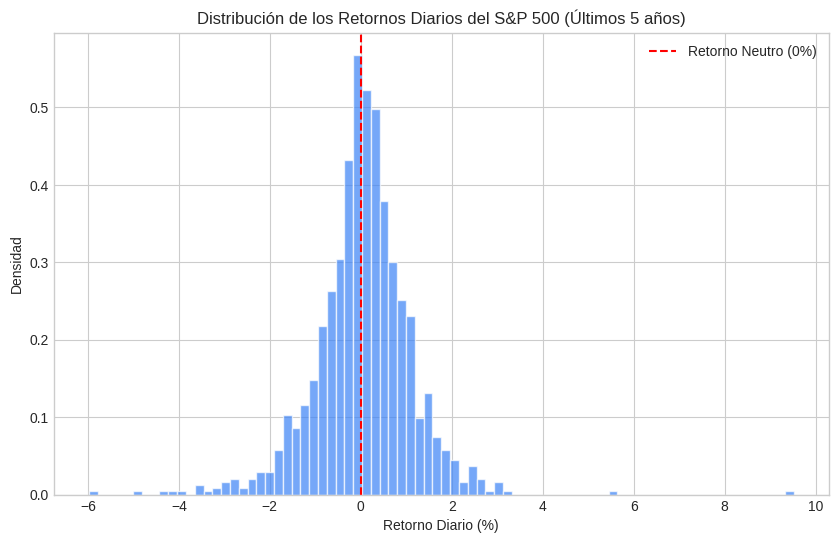

In [ ]:
# ==========================================
# 3. HISTOGRAMA
# ==========================================

retornos = sp500['retorno_diario']*100 # Multiplicamos por 100 para verlo en porcentaje

plt.figure(figsize=(10, 6))
# Usamos density=True para que el área del histograma sume 1 (como una Función de Densidad PDF)
# Si density=False, en el eje vertical se mostrará el conteo de los datos que caen en cada bin
plt.hist(retornos, bins=80, color='#3b82f6', edgecolor='white', density=True, alpha=0.7)
plt.axvline(0, color='red', linestyle='dashed', linewidth=1.5, label='Retorno Neutro (0%)')

plt.title('Distribución de los Retornos Diarios del S&P 500 (Últimos 5 años)')
plt.xlabel('Retorno Diario (%)')
plt.ylabel('Densidad')
plt.legend()
plt.show()

# CALCULE EL RETORNO ANUAL PROMEDIO. ¿ES RENTABLE INVERTIR EN LA BOLSA?


**RESPUESTA:** ¡Sí! La gráfica de la distribución se parece mucho a una distribución Normal (Gaussiana).

In [ ]:
# ==========================================
# RETORNO ANUAL PROMEDIO
# ==========================================
retorno_diario_promedio = sp500['retorno_diario'].mean()
retorno_anual_promedio  = retorno_diario_promedio * 252  # 252 días hábiles de bolsa en un año

print("=" * 50)
print("  ¿ES RENTABLE INVERTIR EN EL S&P 500?")
print("=" * 50)
print(f"  Retorno diario promedio  : {retorno_diario_promedio*100:.4f}%")
print(f"  Retorno anual promedio   : {retorno_anual_promedio*100:.2f}%")
print("=" * 50)
print(f"  Si es rentable, supera por mas de 10% la ganancia de retorno anual")

  ¿ES RENTABLE INVERTIR EN EL S&P 500?
  Retorno diario promedio  : 0.0519%
  Retorno anual promedio   : 13.09%
  Si es rentable, supera por mas de 10% la ganancia de retorno anual


## 2. Cuartiles y Percentiles

Hasta ahora hemos visto el histograma, que nos muestra dónde se agrupan los datos. Pero, ¿cómo podemos *ranquear* esos datos? Para eso usamos los **Percentiles**.

Imaginemos que tomamos los 1,250 días de retornos del S&P 500 y los formamos en una fila:
* A la extrema izquierda ponemos el peor día de todos (la mayor caída).
* A la extrema derecha ponemos el mejor día (la mayor ganancia).
* En el medio quedan los días "normales".

Si empezamos a caminar desde la izquierda (los peores días) hacia la derecha, y nos detenemos cuando hemos pasado exactamente al **10%** de los datos de la fila, el valor del retorno en ese punto exacto es el **Percentil 10**. Significa que el 10% de los días fueron peores que ese valor, y el 90% fueron mejores.

Matemáticamente, el **Percentil $p$** es el valor $x$ donde la probabilidad acumulada es exactamente $p\%$.
* En fórmula, es el valor de $x$ para el que $F_X(x) = p/100$

Por su parte, los **Cuartiles** son simplemente percentiles con nombres especiales que cortan nuestra fila de datos en cuatro pedazos iguales (de 25% en 25%):
* **Q1 (Primer Cuartil o Percentil 25):** Sólo el 25% de los datos es menor a este valor.
* **Q2 (Mediana o Percentil 50):** Corta la fila exactamente por la mitad.
* **Q3 (Tercer Cuartil o Percentil 75):** El 75% de los datos es menor a este valor.

In [ ]:
# ==========================================
# 4. CÁLCULO DE CUARTILES
# ==========================================


# En Pandas, la función .quantile() hace exactamente el trabajo de
# "ordenar la fila y buscar la posición" por nosotros. Recibe un valor entre 0 y 1.

q1 = retornos.quantile(0.25) # Avanzamos el 25% de la fila
q2 = retornos.quantile(0.50) # Avanzamos a la mitad exacta (Mediana)
q3 = retornos.quantile(0.75) # Avanzamos el 75% de la fila

print("--- LOS CUARTILES DEL S&P 500 ---")
print(f"Q1 (Percentil 25): {q1:.3f}%  -> Solo el 25% de los días el mercado rindió menos que esto.")
print(f"Q2 (Percentil 50): {q2:.3f}%  -> La mitad de los días fueron peores que esto.")
print(f"Q3 (Percentil 75): {q3:.3f}%  -> El 75% de los días fueron peores que esto.")


--- LOS CUARTILES DEL S&P 500 ---
Q1 (Percentil 25): -0.467%  -> Solo el 25% de los días el mercado rindió menos que esto.
Q2 (Percentil 50): 0.082%  -> La mitad de los días fueron peores que esto.
Q3 (Percentil 75): 0.618%  -> El 75% de los días fueron peores que esto.


# Reto 1: Peores Escenarios y los "Cisnes Negros"

En finanzas, un "Cisne Negro" es un evento extremadamente raro y de gran impacto. Vamos a buscar esos días de pánico en el histórico del S&P 500.

**Entregables:**
1. **Calcular el Percentil 1** de los retornos diarios (umbral del 1% de los peores días posibles).
2. Si alguien tiene invertido en el S&P 500 10.000 USD ¿a cuántos dólares de pérdida equivale ese porcentaje?
3. **Caza de Cisnes Negros:** Usando el valor del percentil calculado para filtrar el DataFrame `sp500`, mostrar las fechas exactas donde el mercado tuvo retornos peores que ese umbral.
4. ¿Puedes relacionar alguno de estos peores días con algún evento histórico o crisis mundial reciente?

In [ ]:
# ==========================================
# RETO 1: PEORES ESCENARIOS Y CISNES NEGROS
# ==========================================

# --- 1. Percentil 1 (umbral del 1% de los peores días) ---
p1 = retornos.quantile(0.01)

print("=" * 55)
print("  RETO 1: PEORES ESCENARIOS Y CISNES NEGROS")
print("=" * 55)
print(f"\n  1. Percentil 1 : {p1:.3f}%")
print(f"     Solo el 1% de los días el mercado cayó más que esto.")

# --- 2. Pérdida en dólares ---
inversion     = 10_000  # USD
perdida_usd   = inversion * (p1 / 100)
print(f"\n  2. Pérdida equivalente sobre $10,000 USD invertidos:")
print(f"     Con Percentil 1 : {p1:.3f}% hay ${perdida_usd:.2f} USD de perdidas en un solo día")

# --- 3. Caza de Cisnes Negros ---
# Filtramos los días donde el retorno fue PEOR que el percentil 1
cisnes_negros = sp500[sp500['retorno_diario'] * 100 < p1].copy()
cisnes_negros['retorno(%)'] = cisnes_negros['retorno_diario'] * 100
# Se eliminan columnas que no sean de importancia y se ordena de **peor a mejor** (de más negativo a menos negativo)
cisnes_negros = cisnes_negros[['precio', 'retorno(%)']].sort_values( by='retorno(%)', ascending=True)

print(f"\n  3. Días con retornos peores que {p1:.3f}% (Cisnes Negros):")
print(f"     Total de días encontrados: {len(cisnes_negros)}")
display(cisnes_negros)


  RETO 1: PEORES ESCENARIOS Y CISNES NEGROS

  1. Percentil 1 : -2.950%
     Solo el 1% de los días el mercado cayó más que esto.

  2. Pérdida equivalente sobre $10,000 USD invertidos:
     Con Percentil 1 : -2.950% hay $-295.05 USD de perdidas en un solo día

  3. Días con retornos peores que -2.950% (Cisnes Negros):
     Total de días encontrados: 13


,precio,retorno(%)
fecha,,
2025-04-04,5074.080078,-5.974961
2025-04-03,5396.520020,-4.839563
2022-09-13,3932.689941,-4.323661
2022-05-18,3923.679932,-4.039526
2022-06-13,3749.629883,-3.876843
2022-04-29,4131.930176,-3.628451
2022-05-05,4146.870117,-3.564971
2025-04-10,5268.049805,-3.460758
2022-08-26,4057.659912,-3.368806


## 4. Relación con Eventos Históricos

Al filtrar el 1% de los peores días del S&P 500, encontramos 13 fechas agrupadas en torno a 4 grandes eventos:


*   **Guerra Arancelaria de Trump (Abril 2025)**

**2025-04-04 (-5.97%)**, **2025-04-03 (-4.84%)** y **2025-04-10 (-3.46%)** son los tres peores días de la muestra.
El presidente Trump anunció aranceles masivos contra prácticamente todos los socios comerciales de EE.UU.,
desatando temores de una guerra comercial global y una posible recesión.

*   **Ciclo de Alzas de Tasas de la Fed (2022)**

**2022-09-13 (-4.32%)**, **2022-05-18 (-4.04%)**, **2022-06-13 (-3.88%)**, **2022-04-29 (-3.63%)**,
**2022-05-05 (-3.56%)**, **2022-08-26 (-3.37%)**, **2022-06-16 (-3.25%)**, **2022-05-09 (-3.20%)**
y **2022-03-07 (-2.95%)** forman el cluster más denso.
La Reserva Federal subió tasas agresivamente para combatir la inflación post-pandemia,
generando el peor año para el S&P 500 desde 2008. El discurso de Powell en Jackson Hole
(agosto 2022) eliminó cualquier esperanza de un giro en la política monetaria.

* Pánico por Recesión en EE.UU. (Agosto 2024)

**2024-08-05 (-3.00%)**: el dato de empleo de julio 2024 salió muy por debajo de lo esperado,
activando la **Regla de Sahm** (indicador de recesión), lo que desató ventas masivas en un solo día.

### Conclusión:
Los cisnes negros no son eventos aislados: siempre tienen una narrativa macroeconómica detrás.
El evento dominante en esta muestra es el **ciclo de alzas de tasas de 2022**,
responsable de 9 de los 13 peores días. El COVID-19 no aparece
porque los datos cubren los últimos 5 años (2020 quedó fuera del rango de descarga).